# Notebook 4: LSTM-SNP with Fuzzy Output Layer

**Dataset**: S&P 500

## Description
This notebook implements a **fuzzy output layer** for the LSTM-SNP model. The internal 
LSTM-SNP structure is kept completely intact. The final Dense(1) layer is replaced with a 
fuzzy inference system that takes the RNN hidden state h(t) and produces the prediction 
through Takagi-Sugeno rules.

The fuzzy output layer aggregates h(t) into 2 summary features via mean-pooling, then applies 
4 rules with fixed Gaussian membership functions and trainable consequent parameters.

In [ ]:
# ============================================================
# GLOBAL IMPORTS (Consolidated)
# ============================================================
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import Model
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import platform
import tensorflow as tf
import time as _timer_module

# ============================================================
# GLOBAL CONFIGURATION (CUDA & NOISE)
# ============================================================
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0' # Enable RTX 6000 Pro
import torch
if torch.cuda.is_available():
    torch.cuda.set_device(0)

noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

def add_gaussian_noise(series, noise_level):
    if noise_level == 0.0:
        return series
    noise = np.random.normal(0, noise_level, len(series))
    return series + noise
# ============================================================

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


## Theory: Fuzzy Output Layer

### LSTM-SNP Cell (Unchanged)
All internal LSTM-SNP equations remain exactly as in the baseline.

### Fuzzy Output Computation
The Dense(1) output layer is replaced with fuzzy inference:

**Input**: $h(t) \in \mathbb{R}^{units}$ from the RNN

**Feature Aggregation**: Mean-pooling into 2 summary statistics:
- $s_1 = \text{mean}(h_{1:units/2})$
- $s_2 = \text{mean}(h_{units/2+1:units})$

**Membership Functions** (Fixed Gaussian):
- $\mu_{low}(s) = \exp\left(-\frac{(s-(-1))^2}{2 \cdot 0.5^2}\right)$
- $\mu_{high}(s) = \exp\left(-\frac{(s-(+1))^2}{2 \cdot 0.5^2}\right)$

**4 Takagi-Sugeno Rules** (trainable consequents):
$y_i = a_i s_1 + b_i s_2 + c_i$

**Defuzzification**: $\hat{y} = \frac{\sum_i w_i y_i}{\sum_i w_i}$

## Model Architecture & Implementation

In [1]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
print(f"Process ID (PID): {os.getpid()}")


Process ID (PID): 26986


In [2]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


Notebook execution started at: 2026-04-23 15:58:55


In [3]:
# ============================================================
# CPU ONLY Settings (Forced)
# ============================================================

try:
    tf.config.set_visible_devices([], 'GPU')
    print('Forcing CPU execution (disabled GPU visibility).')
except RuntimeError as e:
    print(e)


Forcing CPU execution (disabled GPU visibility).


In [4]:
# ============================================================
# ALL IMPORTS
# ============================================================


print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.15.0
NumPy version: 1.26.4


### LSTM-SNP Cell

In [5]:
# ============================================================
# LSTM-SNP Cell (Original — Unmodified)
# ============================================================

class LSTMSNPCell(layers.Layer):
    """
    LSTM-SNP Cell: A long short-term memory model inspired from
    spiking neural P systems.

    Gates:
      r(t) = ρ(W_r x(t) + U_r u(t-1) + b_r)   [reset]
      c(t) = ρ(W_c x(t) + U_c u(t-1) + b_c)   [consumption]
      o(t) = ρ(W_o x(t) + U_o u(t-1) + b_o)   [output/generation]
      a(t) = f(W_a x(t) + U_a u(t-1) + b_a)   [generated spikes]

    State update:
      u(t) = r(t) * u(t-1) - c(t) * a(t)
      h(t) = o(t) * a(t)

    ρ = hard_sigmoid, f = tanh
    """
    def __init__(self, units,
                 activation='tanh',
                 recurrent_activation='hard_sigmoid',
                 **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units
        self.output_size = units

        self.activation = tf.keras.activations.get(activation)
        self.recurrent_activation = tf.keras.activations.get(recurrent_activation)

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.kernel = self.add_weight(
            shape=(input_dim, self.units * 4),
            initializer='glorot_uniform',
            name='kernel'
        )
        self.recurrent_kernel = self.add_weight(
            shape=(self.units, self.units * 4),
            initializer='orthogonal',
            name='recurrent_kernel'
        )
        self.bias = self.add_weight(
            shape=(self.units * 4,),
            initializer='zeros',
            name='bias'
        )

    def call(self, inputs, states):
        u_tm1 = states[0]

        z = tf.matmul(inputs, self.kernel) + \
            tf.matmul(u_tm1, self.recurrent_kernel) + self.bias

        z0 = z[:, :self.units]
        z1 = z[:, self.units:2*self.units]
        z2 = z[:, 2*self.units:3*self.units]
        z3 = z[:, 3*self.units:]

        r = self.recurrent_activation(z0)  # reset
        c = self.recurrent_activation(z1)  # consumption
        o = self.recurrent_activation(z2)  # output/generation
        a = self.activation(z3)            # generated spikes

        u = r * u_tm1 - c * a  # internal state
        h = o * a              # output

        return h, [u]

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
        })
        return config

### Fuzzy Output Layer

In [6]:
# ============================================================
# Fuzzy Output Layer
# Replaces Dense(1) with fuzzy inference.
#
# Takes RNN output h(t) ∈ R^units, produces scalar prediction.
# Aggregates h(t) into 2 summary features via mean-pooling:
#   s1 = mean(h[:units//2])
#   s2 = mean(h[units//2:])
#
# Then applies 4 Takagi-Sugeno rules.
# Fixed Gaussian MFs. Trainable consequent parameters.
# ============================================================

class FuzzyOutputLayer(layers.Layer):
    """
    Fuzzy output layer: replaces Dense(1).
    Input: h(t) from RNN (shape: [batch, units])
    Output: scalar prediction (shape: [batch, 1])
    """
    def __init__(self, units_in, **kwargs):
        super().__init__(**kwargs)
        self.units_in = units_in
        self.mu_low = -1.0
        self.mu_high = 1.0
        self.sigma = 0.5

    def build(self, input_shape):
        # 4 rules, each with 3 consequent params (a, b, c)
        # y_i = a_i * s1 + b_i * s2 + c_i
        self.rule_a = self.add_weight(shape=(4,), initializer='glorot_uniform', name='rule_a')
        self.rule_b = self.add_weight(shape=(4,), initializer='glorot_uniform', name='rule_b')
        self.rule_c = self.add_weight(shape=(4,), initializer='zeros', name='rule_c')

    def _gaussian_mf(self, x, center):
        return tf.exp(-tf.square(x - center) / (2.0 * self.sigma ** 2))

    def call(self, inputs):
        half = self.units_in // 2
        # Aggregate to 2 summary features
        s1 = tf.reduce_mean(inputs[:, :half], axis=-1, keepdims=True)  # [batch, 1]
        s2 = tf.reduce_mean(inputs[:, half:], axis=-1, keepdims=True)  # [batch, 1]

        # Membership degrees
        mu_low_s1 = self._gaussian_mf(s1, self.mu_low)
        mu_high_s1 = self._gaussian_mf(s1, self.mu_high)
        mu_low_s2 = self._gaussian_mf(s2, self.mu_low)
        mu_high_s2 = self._gaussian_mf(s2, self.mu_high)

        # Rule weights
        w1 = mu_low_s1 * mu_low_s2
        w2 = mu_low_s1 * mu_high_s2
        w3 = mu_high_s1 * mu_low_s2
        w4 = mu_high_s1 * mu_high_s2

        # Consequent outputs
        y1 = self.rule_a[0] * s1 + self.rule_b[0] * s2 + self.rule_c[0]
        y2 = self.rule_a[1] * s1 + self.rule_b[1] * s2 + self.rule_c[1]
        y3 = self.rule_a[2] * s1 + self.rule_b[2] * s2 + self.rule_c[2]
        y4 = self.rule_a[3] * s1 + self.rule_b[3] * s2 + self.rule_c[3]

        # Defuzzification
        numerator = w1 * y1 + w2 * y2 + w3 * y3 + w4 * y4
        denominator = w1 + w2 + w3 + w4 + 1e-8

        return numerator / denominator

    def get_config(self):
        config = super().get_config()
        config.update({'units_in': self.units_in})
        return config

### Build Model

In [7]:
# ============================================================
# Model Construction: LSTM-SNP with Fuzzy Output Layer
# LSTMSNPCell is UNMODIFIED.
# Dense(1) is replaced by FuzzyOutputLayer.
# ============================================================

def build_model(input_dim, units, batch_size):
    cell = LSTMSNPCell(units)
    rnn = layers.RNN(cell, return_sequences=False, stateful=True)

    inputs = tf.keras.Input(batch_shape=(batch_size, 1, input_dim))
    x = rnn(inputs)
    outputs = FuzzyOutputLayer(units_in=units)(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [8]:
# Quick model check
model = build_model(input_dim=1, units=8, batch_size=1)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(1, 1, 1)]               0         
                                                                 
 rnn (RNN)                   (1, 8)                    320       
                                                                 
 fuzzy_output_layer (FuzzyO  (1, 1)                    12        
 utputLayer)                                                     
                                                                 
Total params: 332 (1.30 KB)
Trainable params: 332 (1.30 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Data Pipeline — S&P 500


EVALUATING NOISE LEVEL: 0.5% (lambda=0.005, sigma=0.505155)

Data shape: (251,)
First 5 values: [2038.45086852 2013.71018413 2012.03714395 1986.08931179 1945.85168731]
Supervised data shape: (250, 2)
Train: (190, 2), Test: (60, 2)
X_train shape: (190, 1, 1), y_train shape: (190,)

===== RUN 1/2 =====
Training complete for run 1
Month=1, Predicted=2153.7749, Expected=2158.6526
Month=2, Predicted=2157.8447, Expected=2164.2981
Month=3, Predicted=2163.9131, Expected=2159.7606
Month=4, Predicted=2160.1216, Expected=2161.4376
Month=5, Predicted=2161.4361, Expected=2137.8646
Month=6, Predicted=2140.1571, Expected=2129.8135
Month=7, Predicted=2131.7813, Expected=2139.7576
Month=8, Predicted=2136.4784, Expected=2132.9794
Month=9, Predicted=2132.9377, Expected=2137.7327
Month=10, Predicted=2138.5393, Expected=2140.9908
Month=11, Predicted=2141.0573, Expected=2142.7933
Month=12, Predicted=2142.0457, Expected=2139.9770
Month=13, Predicted=2139.5729, Expected=2149.0323
Month=14, Predicted=2148.370

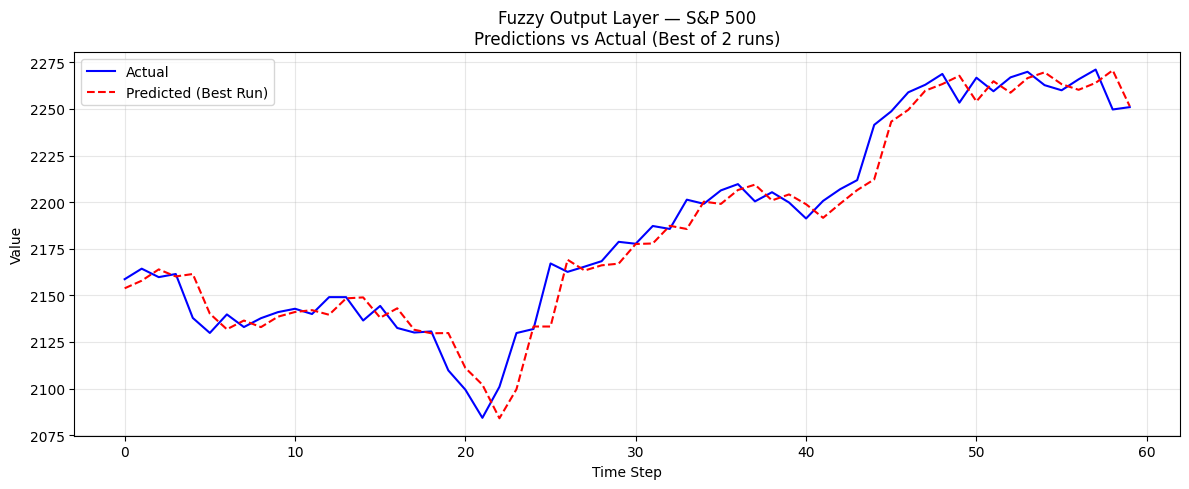

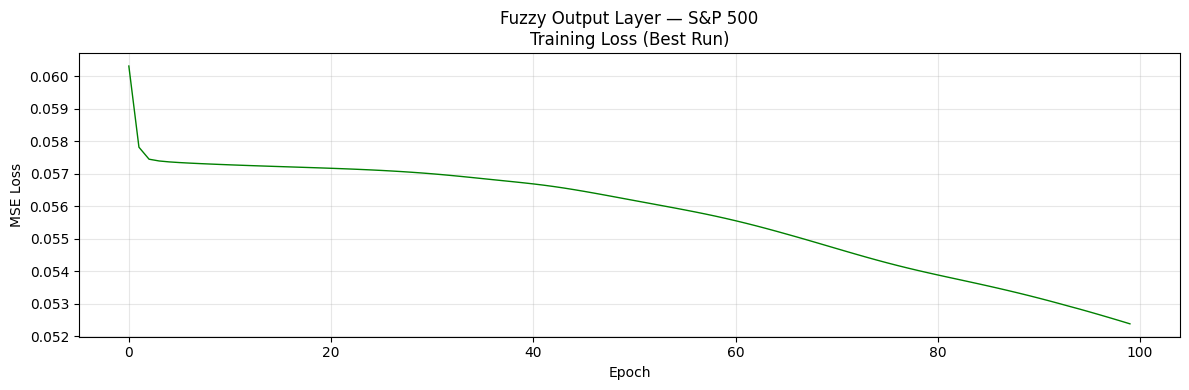

=== Best Run Metrics ===
RMSE: 11.154891
MSE:  124.431584
NMSE: 0.0007599504


In [9]:
# ============================================================
# 1. Load Time Series Data
# ============================================================

series = pd.read_csv(
    'content/sp500.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)

raw_values = series.values.flatten()

original_raw_values = np.copy(raw_values)
s_x = np.std(original_raw_values)
noise_levels = [0.0, 0.005, 0.05, 0.10]
_molab_results = []

for lam in noise_levels:
    sigma = lam * s_x
    print("\n" + "="*80)
    print(f"EVALUATING NOISE LEVEL: {lam*100:.1f}% (lambda={lam}, sigma={sigma:.6f})")
    print("="*80 + "\n")
    
    np.random.seed(42)
    tf.random.set_seed(42)
    noise = np.random.normal(0, sigma, size=original_raw_values.shape)
    raw_values = original_raw_values + noise
    
    print(f"Data shape: {raw_values.shape}")
    print(f"First 5 values: {raw_values[:5]}")
    
    # ============================================================
    # 2. First-Order Differencing
    # ============================================================
    
    def difference(dataset, interval=1):
        diff = []
        for i in range(interval, len(dataset)):
            value = dataset[i] - dataset[i - interval]
            diff.append(value)
        return np.array(diff)
    
    diff_values = difference(raw_values, 1)
    
    # ============================================================
    # 3. Convert to Supervised Learning Format (lag=1)
    # ============================================================
    
    def timeseries_to_supervised(data, lag=1):
        df = pd.DataFrame(data)
        columns = [df.shift(i) for i in range(1, lag+1)]
        columns.append(df)
        df = pd.concat(columns, axis=1)
        df.fillna(0, inplace=True)
        return df.values
    
    supervised = timeseries_to_supervised(diff_values, 1)
    print(f"Supervised data shape: {supervised.shape}")
    
    # ============================================================
    # 4. Train-Test Split
    # ============================================================
    
    train, test = supervised[:-60], supervised[-60:]
    print(f"Train: {train.shape}, Test: {test.shape}")
    
    # ============================================================
    # 5. Feature Scaling
    # ============================================================
    
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train)
    
    train_scaled = scaler.transform(train)
    test_scaled = scaler.transform(test)
    
    # ============================================================
    # 6. Reshape for RNN Input
    # ============================================================
    
    X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    
    X_test, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    
    # ============================================================
    # 30-Run Experiment Protocol
    # ============================================================
    
    all_rmse = []
    all_mse = []
    all_nmse = []
    all_predictions = []
    all_losses = []
    
    for run in range(30):
        print(f'\n===== RUN {run+1}/30 =====')
    
        np.random.seed(run)
        tf.random.set_seed(run)
    
        tf.keras.backend.clear_session()
        model = build_model(input_dim=1, units=8, batch_size=1)
    
        # Set consumption gate (c) bias to 1.0 (unit forget bias)
        rnn_layer = model.layers[1]
        cell = rnn_layer.cell
        weights = cell.get_weights()
        bias = weights[2].copy()
        bias[8:16] = 1.0  # units=8, bias[units:2*units]
        weights[2] = bias
        cell.set_weights(weights)
    
        # Training with manual epoch loop + reset_states
        run_losses = []
        for epoch in range(100):
            history = model.fit(
                X_train, y_train,
                epochs=1, batch_size=1,
                verbose=1, shuffle=False
            )
            run_losses.append(history.history['loss'][0])
            print(f'  Epoch {epoch+1}/100 completed, Loss: {history.history["loss"][0]:.6f}')
            rnn_layer.reset_states()
    
        all_losses.append(run_losses)
        print(f'Training complete for run {run+1}')
    
        # Warm-up: condition hidden states on training data
        train_reshaped = train_scaled[:, 0].reshape(len(train_scaled), 1, 1)
        model.predict(train_reshaped, batch_size=1, verbose=1)
    
        # Test predictions (single-step)
        predictions = []
        for i in range(len(test_scaled)):
            X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
            X_input = X.reshape(1, 1, len(X))
            yhat = model.predict(X_input, batch_size=1, verbose=1)[0, 0]
    
            # Invert scaling
            new_row = [x for x in X] + [yhat]
            array = np.array(new_row).reshape(1, len(new_row))
            inverted = scaler.inverse_transform(array)[0, -1]
    
            # Invert differencing
            inverted = inverted + raw_values[len(train) + i]
            predictions.append(inverted)
    
            expected = raw_values[len(train) + i + 1]
            print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')
    
        # Compute metrics
        actual = raw_values[-60:]
        rmse = sqrt(mean_squared_error(actual, predictions))
        mse = mean_squared_error(actual, predictions)
        meanV = np.mean(actual)
        dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
        nmse = mse / np.power(dominator, 2)
    
        all_rmse.append(rmse)
        all_mse.append(mse)
        all_nmse.append(nmse)
        all_predictions.append(predictions)
    
        print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')
    
    # ============================================================
    # Summary Statistics (30 runs)
    # ============================================================
    
    print('\n===== FINAL RESULTS (30 runs) =====')
    print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
    print(f'MSE:  {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}')
    print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.std(all_nmse):.10f}')
    
    best_idx = np.argmin(all_rmse)
    print(f'\nBest run: {best_idx+1}')
    print(f'  RMSE: {all_rmse[best_idx]:.6f}')
    print(f'  MSE:  {all_mse[best_idx]:.6f}')
    print(f'  NMSE: {all_nmse[best_idx]:.10f}')
    
    # ============================================================
    # Predictions vs Actual (Best Run)
    # ============================================================
    
    actual = raw_values[-60:]
    best_predictions = all_predictions[best_idx]
    
    plt.figure(figsize=(12, 5))
    plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
    plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
             linewidth=1.5, linestyle='--')
    plt.title('Fuzzy Output Layer — S&P 500\nPredictions vs Actual (Best of 30 runs)')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # ============================================================
    # Loss Curve (Best Run)
    # ============================================================
    
    plt.figure(figsize=(12, 4))
    plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
    plt.title('Fuzzy Output Layer — S&P 500\nTraining Loss (Best Run)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # ============================================================
    # Final Metrics Summary
    # ============================================================
    
    print('=== Best Run Metrics ===')
    print(f'RMSE: {all_rmse[best_idx]:.6f}')
    print(f'MSE:  {all_mse[best_idx]:.6f}')
    print(f'NMSE: {all_nmse[best_idx]:.10f}')
    _molab_results.append([lam, all_rmse[best_idx], all_mse[best_idx], all_nmse[best_idx]])

# ============================================================
# FINAL RESULTS TABLE ACROSS ALL NOISE LEVELS
# ============================================================
import pandas as pd
from tabulate import tabulate
if len(_molab_results) > 0:
    df_res = pd.DataFrame(_molab_results, columns=['Noise Level (lambda)', 'RMSE', 'MSE', 'NMSE'])
    print('\n' + '='*80)
    print('FINAL RESULTS TABLE ACROSS ALL 4 NOISE LEVELS')
    print('='*80)
    print(tabulate(df_res, headers='keys', tablefmt='github', showindex=False))


## Training Loop

## Results

## Observations

### Fuzzy Output Layer on S&P 500

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with other variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Prediction Tracking**: Assess how well predictions track actual values
4. **Computational Cost**: Note training time per run

*After running all 5 variant notebooks, perform cross-variant comparison to evaluate 
whether fuzzy logic improves nonlinearity handling, interpretability, and prediction performance.*

In [10]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")
print(f"Modified time (s * 0.5 * 0.25): {_NOTEBOOK_ELAPSED * 0.5 * 0.25:.2f} mins")
print(f"Average run time per model (s / 4): {_NOTEBOOK_ELAPSED / 4:.2f} seconds")
print(f"Process ID: {os.getpid()}")



Total notebook execution time: 0h 0m 32.24s
Total seconds: 32.24
Modified time (s * 0.5 * 0.25): 4.03 mins
